In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = sns.load_dataset("tips")
df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB



---
# Line plot
- A line plot visualizes how a continuous variable changes with respect to another ordered variable, most commonly time, index, or sequence.

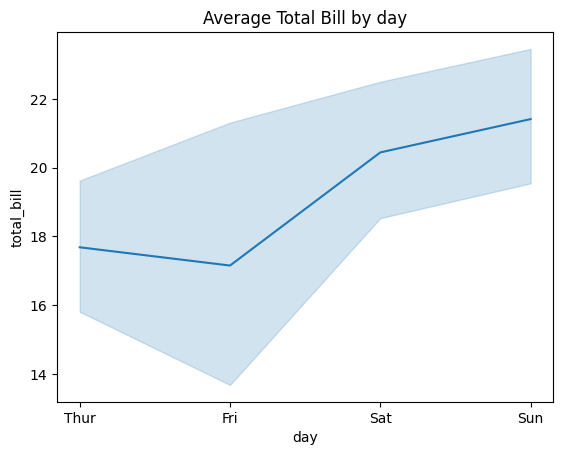

In [22]:
sns.lineplot(
    data=df,
    x="day",
    y="total_bill"
)
plt.title("Average Total Bill by day")
plt.show()

What this bar plot means is 
- Mean total bill per day, with uncertainty

This is statistical aggregation, not raw plotting.

Seaborn is built for **statistical aggregation**, meaning it automatically looks at all the data points for "Thursday," calculates their average (), and plots that single point for you behind the scenes.

Below is how we do it in Matplotlib

/tmp/ipykernel_12264/1339123589.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_bill = df.groupby("day")["total_bill"].mean()


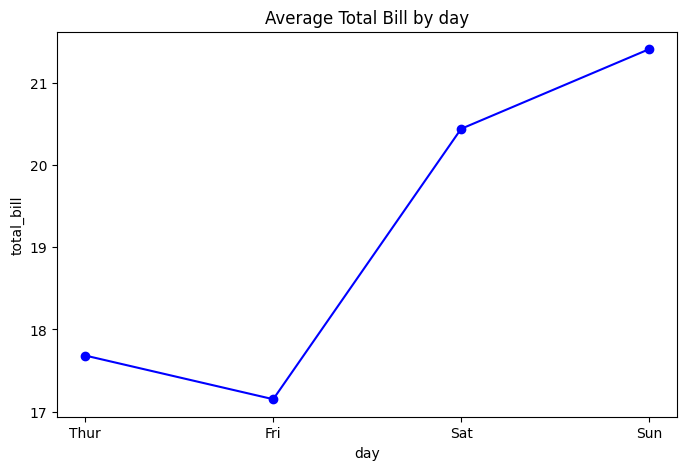

In [23]:
df = sns.load_dataset("tips")

# 1. Group by 'day' and calculate the mean of 'total_bill'
# We sort_values to ensure the days appear in a logical order (Thur -> Sun)
avg_bill = df.groupby("day")["total_bill"].mean()

# 2. Create the plot
plt.figure(figsize=(8, 5))
plt.plot(avg_bill.index, avg_bill.values, marker='o', linestyle='-', color='b')

# 3. Add labels and title
plt.xlabel("day")
plt.ylabel("total_bill")
plt.title("Average Total Bill by day")

# 4. Show the plot
plt.show()

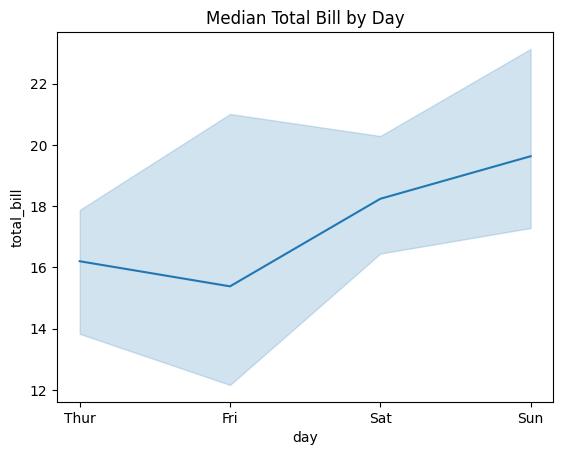

In [24]:
# how to change it to mean. just for demo
# Change the estimator to 'median'
sns.lineplot(data=df, x="day", y="total_bill", estimator="median")

plt.title("Median Total Bill by Day")
plt.show()

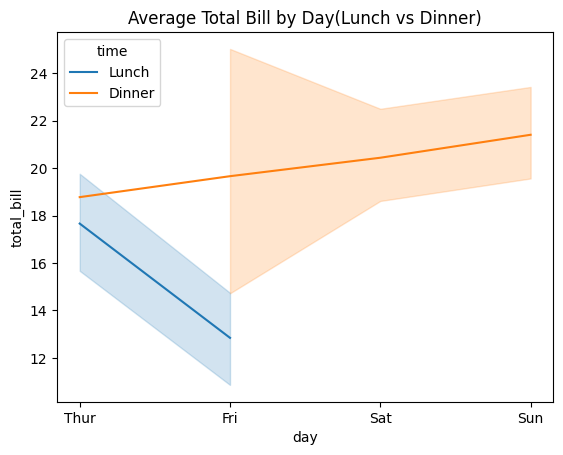

In [25]:
# Now lets compare Lunch vs Dinner trends
sns.lineplot(
    data=df,
    x="day",
    y="total_bill",
    hue="time"
)
plt.title("Average Total Bill by Day(Lunch vs Dinner)")
plt.show()

**Line plot** → use when the x-axis is **ordered/continuous** (time, index, epoch) and you want to show a **trend or change over sequence**.

**Bar plot** → use when the x-axis is **categorical (unordered)** and you want to **compare aggregated values across categories**.


# Scatter plot
Scatter plot → use when you want to analyze the relationship, correlation, or pattern between two continuous variables where points are not inherently ordered and should not be connected.

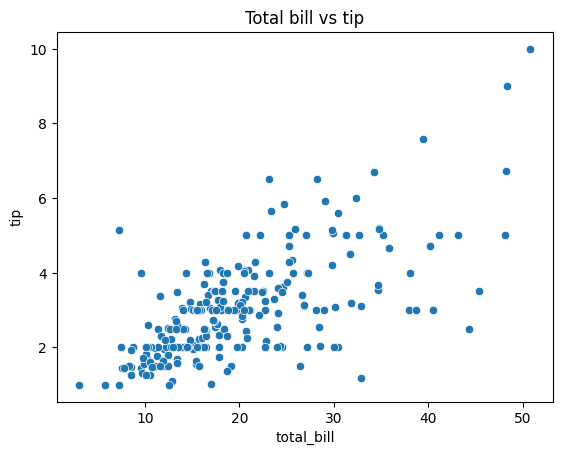

In [26]:
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip"
)
plt.title("Total bill vs tip")
plt.show()

- Positive correlation (higher bill → higher tip)

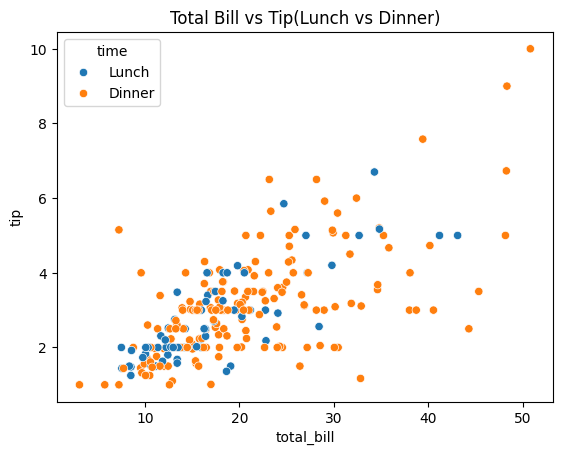

In [27]:
# Scatter plot with a third variable 
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="time"
)
plt.title("Total Bill vs Tip(Lunch vs Dinner)")
plt.show()

Why NOT Line Plot Here?
- Bills are not ordered
- Customers are independent observations
- Connecting points would imply a false sequence

# Histogram

- Histogram → use when you want to visualize the distribution, spread, skewness, and frequency of a single continuous numerical variable.

- A histogram shows the distribution of a single numerical variable. 

EDA questions it answers:

- Is the data skewed or symmetric?

- Where do most values concentrate?

- Are there outliers?

- Is the distribution normal, bimodal, or long-tailed?

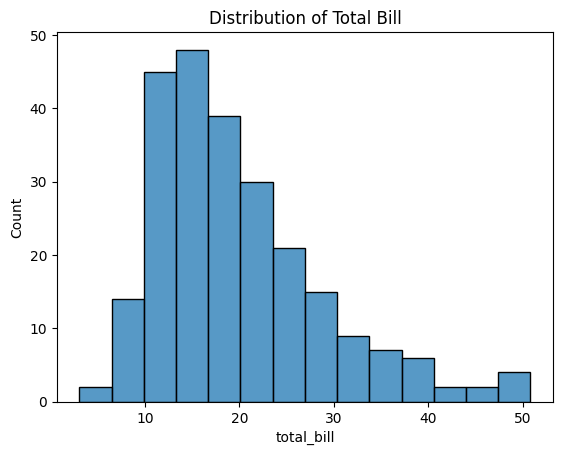

In [28]:
df = sns.load_dataset("tips")

sns.histplot(
    data=df,
    x="total_bill"
)

plt.title("Distribution of Total Bill")
plt.show()

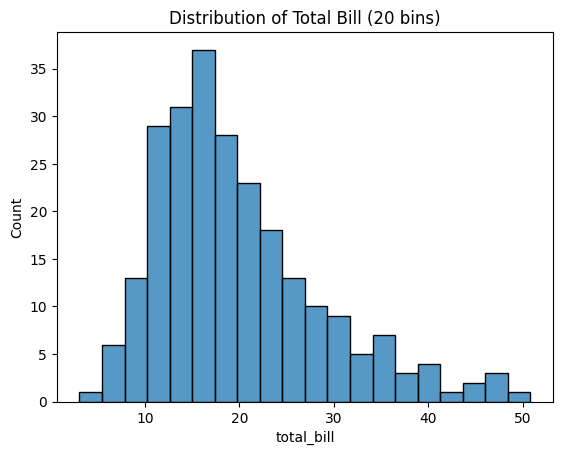

In [29]:
sns.histplot(
    data=df,
    x="total_bill",
    bins=20
)

plt.title("Distribution of Total Bill (20 bins)")
plt.show()


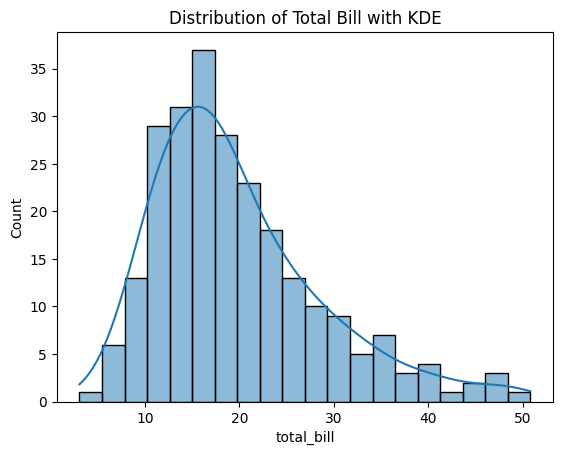

In [30]:
sns.histplot(
    data=df,
    x="total_bill",
    bins=20,
    kde=True
)

plt.title("Distribution of Total Bill with KDE")
plt.show()
# Smooth curve → estimated density

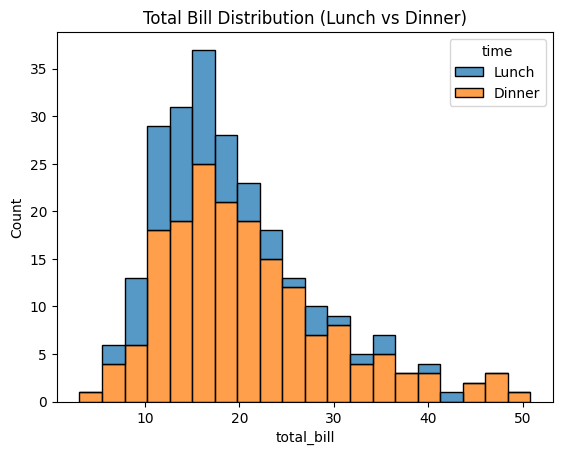

In [31]:
sns.histplot(
    data=df,
    x="total_bill",
    hue="time",
    bins=20,
    multiple="stack"
)

plt.title("Total Bill Distribution (Lunch vs Dinner)")
plt.show()
# Compare Distributions (Histogram by Category)
# Now you are comparing disUse stack when you want both total distribution and category contribution in one view.tributions, not trends or relationships.
# Use stack when you want both total distribution and category contribution in one view.

# Box plot 
- Box plot → use when you want a compact summary of a numerical variable’s distribution, especially to compare groups and identify outliers.

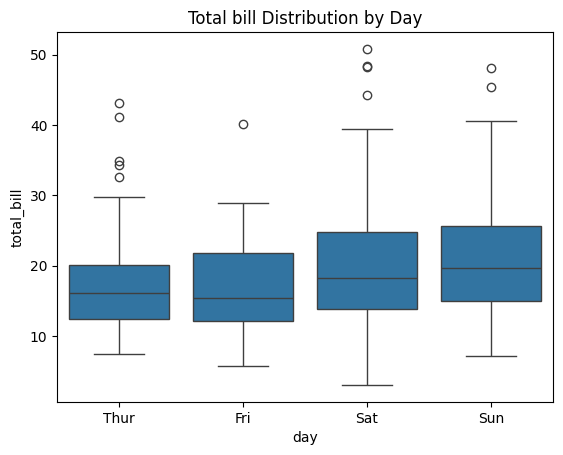

In [32]:
sns.boxplot(
    data=df,
    x="day",
    y="total_bill"
)

plt.title("Total bill Distribution by Day")
plt.show()

**Concise box plot legend**

* **Bottom whisker (lowest line)** → smallest **non-outlier** value
* **Bottom of box** → **Q1 (25th percentile)**
* **Middle line inside box** → **Median (50th percentile)**
* **Top of box** → **Q3 (75th percentile)**
* **Top whisker (highest line)** → largest **non-outlier** value
* **Box (blue area)** → **IQR = Q3 − Q1** (middle 50% of data)
* **Small circles** → **Outliers** (values beyond `Q1 − 1.5×IQR` or `Q3 + 1.5×IQR`)


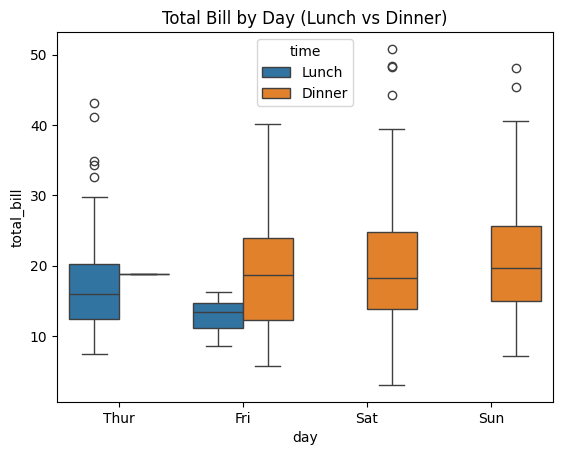

In [33]:
sns.boxplot(
    data=df,
    x="day",
    y="total_bill",
    hue="time"
)

plt.title("Total Bill by Day (Lunch vs Dinner)")
plt.show()


# Bar plot
- Bar plot → use when you want to compare aggregated values (mean, sum, etc.) across categorical groups.


- Each bar height → mean of total_bill for that day

- Error bar → confidence interval (by default, 95%)

- You are seeing aggregated statistics, not raw values

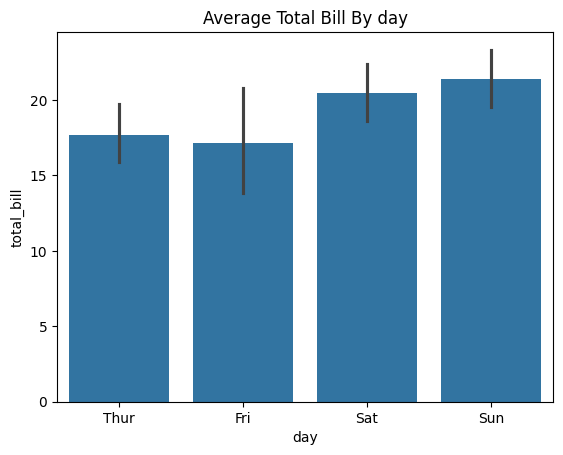

In [34]:
sns.barplot(
    data=df,
    x="day",
    y="total_bill"
)

plt.title("Average Total Bill By day")
plt.show()


## What this bar plot shows (overall)

For each **day**, the plot shows the **average (mean) total bill**.

You are **not** seeing individual bills — only an **aggregated statistic**.

---

## Meaning of each visual element

### 1. Colored bar (rectangle)

* Height of the bar = **mean of `total_bill`** for that day
* Color has **no statistical meaning** here (purely visual)

In words:

> “This is the average bill amount on that day.”

---

### 2. Black line in the middle of the bar

* This is the **error bar**
* By default, Seaborn shows a **95% confidence interval** around the mean

It represents:

> The range where the true population mean is likely to lie

---

## What the error bar is NOT

* Not the minimum or maximum
* Not the median
* Not standard deviation (unless explicitly specified)

---

## Why error bars matter in EDA

They help you judge:

* Whether differences between bars are **statistically meaningful**
* Whether variability is high or low
* Whether apparent differences may be due to noise

If error bars overlap heavily, differences may be weak.


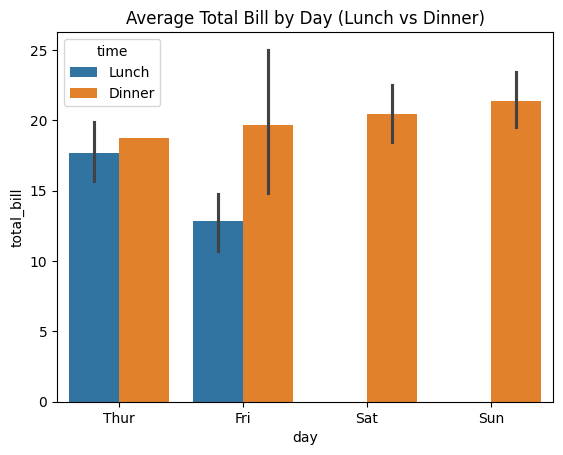

In [35]:
# Compare groups (very common)
sns.barplot(
    data=df,
    x="day",
    y="total_bill",
    hue="time"
)

plt.title("Average Total Bill by Day (Lunch vs Dinner)")
plt.show()


# count plot
- **Count plot** → use when you want to visualize the **frequency (number of observations)** for each **categorical variable**.


<Axes: xlabel='day', ylabel='count'>

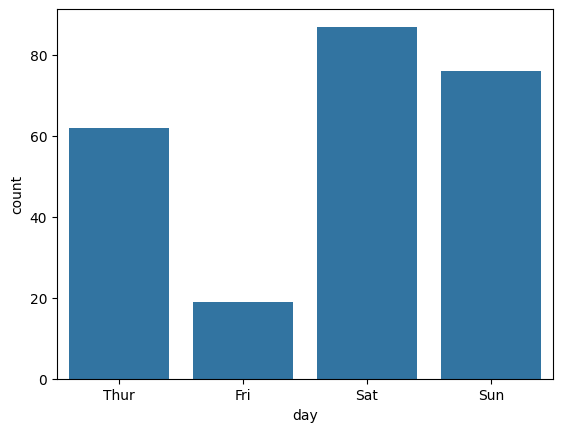

In [37]:
sns.countplot(
    data=df,
    x="day"
)

- Each bar height -> number of rows(observations) for that category
- No averaging, no statistics - pure counts

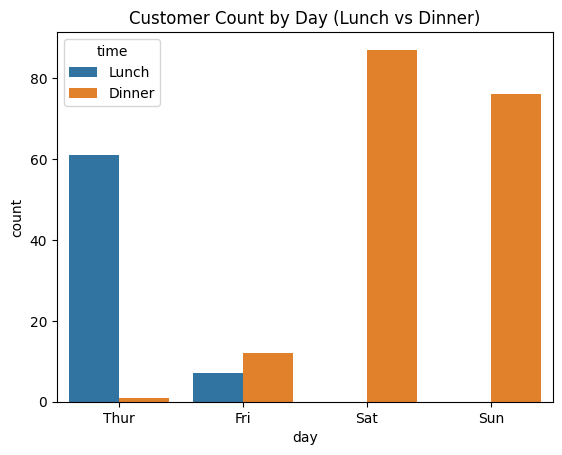

In [38]:
sns.countplot(
    data=df,
    x="day",
    hue="time"
)

plt.title("Customer Count by Day (Lunch vs Dinner)")
plt.show()


Category frequency split by another categorical variable

# correlation heatmap

In [42]:
corr = df[["total_bill","tip","size"]].corr()
corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


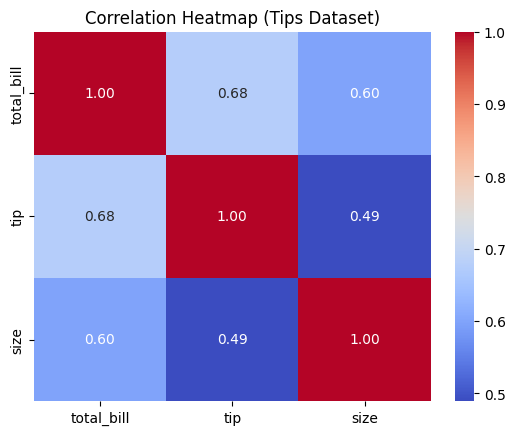

In [43]:
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap (Tips Dataset)")
plt.show()

**Correlation heatmap** → use when you want a **quick visual overview of linear relationships (strength and direction)** between **multiple numerical features**.


# Outlier Visualization

1. Box Plot (most common outlier visualization)

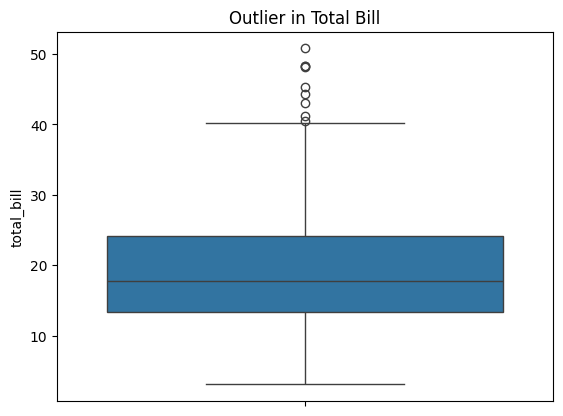

In [48]:
sns.boxplot(
    data=df,
    y="total_bill"
)
plt.title("Outlier in Total Bill")
plt.show()

2. Scatter Plot (index vs value)

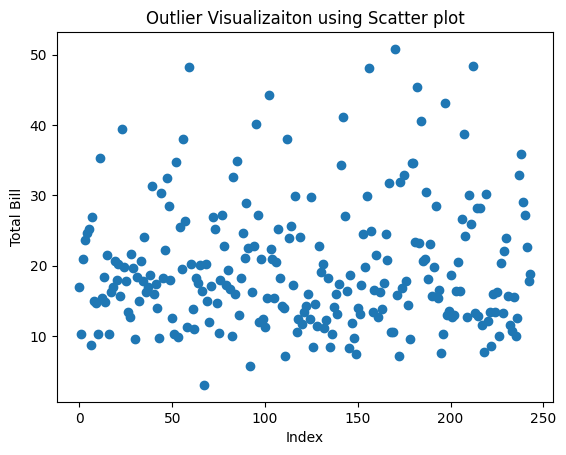

In [50]:
plt.scatter(range(len(df)), df["total_bill"])
plt.xlabel("Index")
plt.ylabel("Total Bill")
plt.title("Outlier Visualizaiton using Scatter plot")
plt.show()

3. Histogram (long-tail detection)

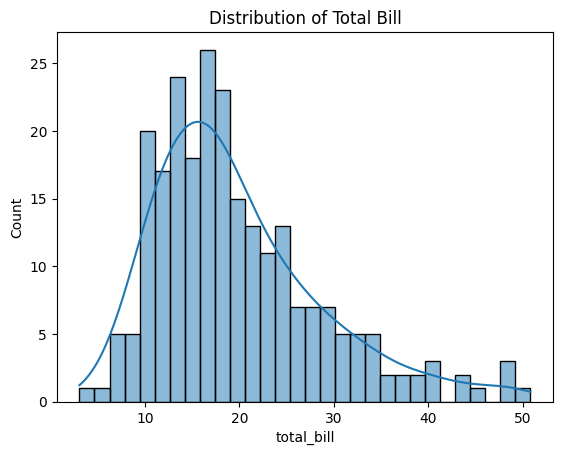

In [56]:
sns.histplot(df["total_bill"], bins=30, kde=True)
plt.title("Distribution of Total Bill")
plt.show()

<Axes: xlabel='total_bill', ylabel='Density'>

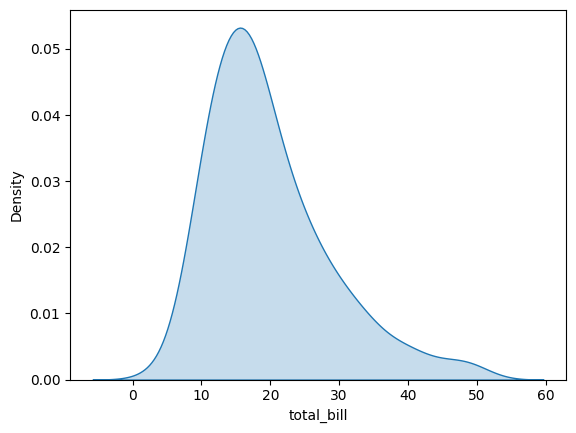

In [ ]:
sns.kdeplot(df["total_bill"], fill=True)

# feature vs target plots

1. Continuous Feature vs Continuous Target (Scatter)

Does total bill affect the tip amount?

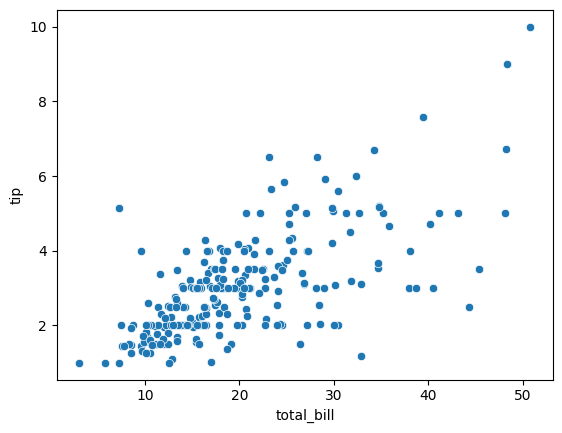

In [69]:
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip"
)
plt.show("Total bill (feature) vs Tip (target)")
plt.show()

2. Feature vs Target with Trend Line (Very Important)

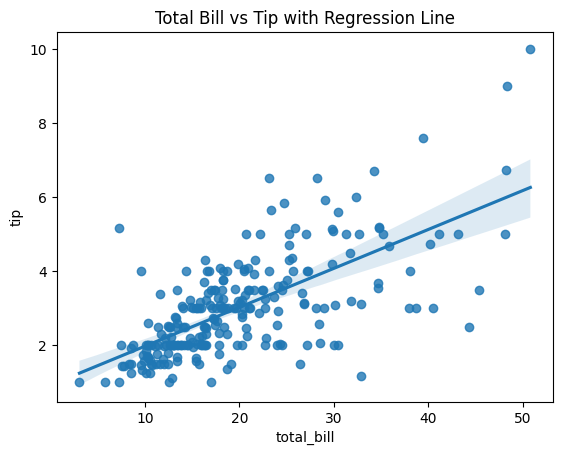

In [70]:
sns.regplot(
    data=df,
    x="total_bill",
    y="tip"
)

plt.title("Total Bill vs Tip with Regression Line")
plt.show()


- Shows linear trend

- Helps judge linearity assumption

- Useful before choosing linear models

regplot → a scatter plot with an automatically fitted regression line to visualize the trend between a feature and a target.

3. Categorical Feature vs Numerical Target (Box Plot)

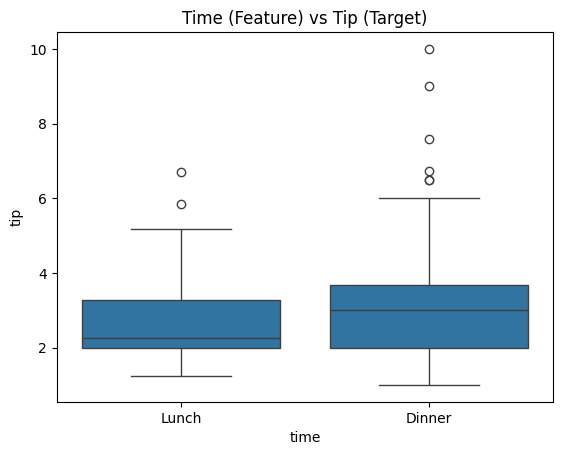

In [71]:
sns.boxplot(
    data=df,
    x="time",
    y="tip"
)

plt.title("Time (Feature) vs Tip (Target)")
plt.show()


- Distribution of target per category

- Median differences

- Outliers

4. Discrete Numerical Feature vs Target (Bar Plot)

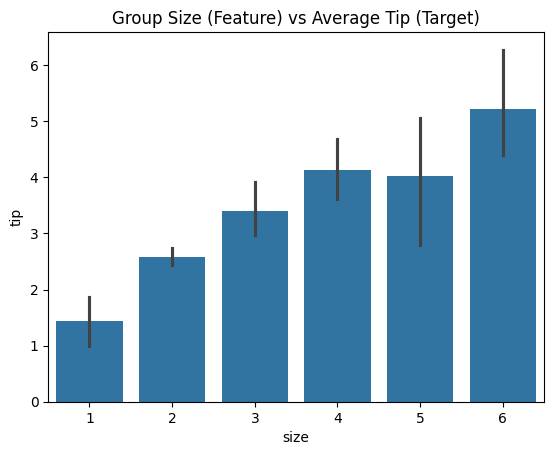

In [72]:
sns.barplot(
    data=df,
    x="size",
    y="tip"
)

plt.title("Group Size (Feature) vs Average Tip (Target)")
plt.show()
